/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines DichroicMirror.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines BandOpticalFilter.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines EdgeOpticalFilter.model as an attribute (dtype: text) while the core schema defines it as a link t

{'nwb_file_name': 'Lily20251217_.nwb', 'epoch': 3, 'block': 1}: HexmazeNoStim


/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altere

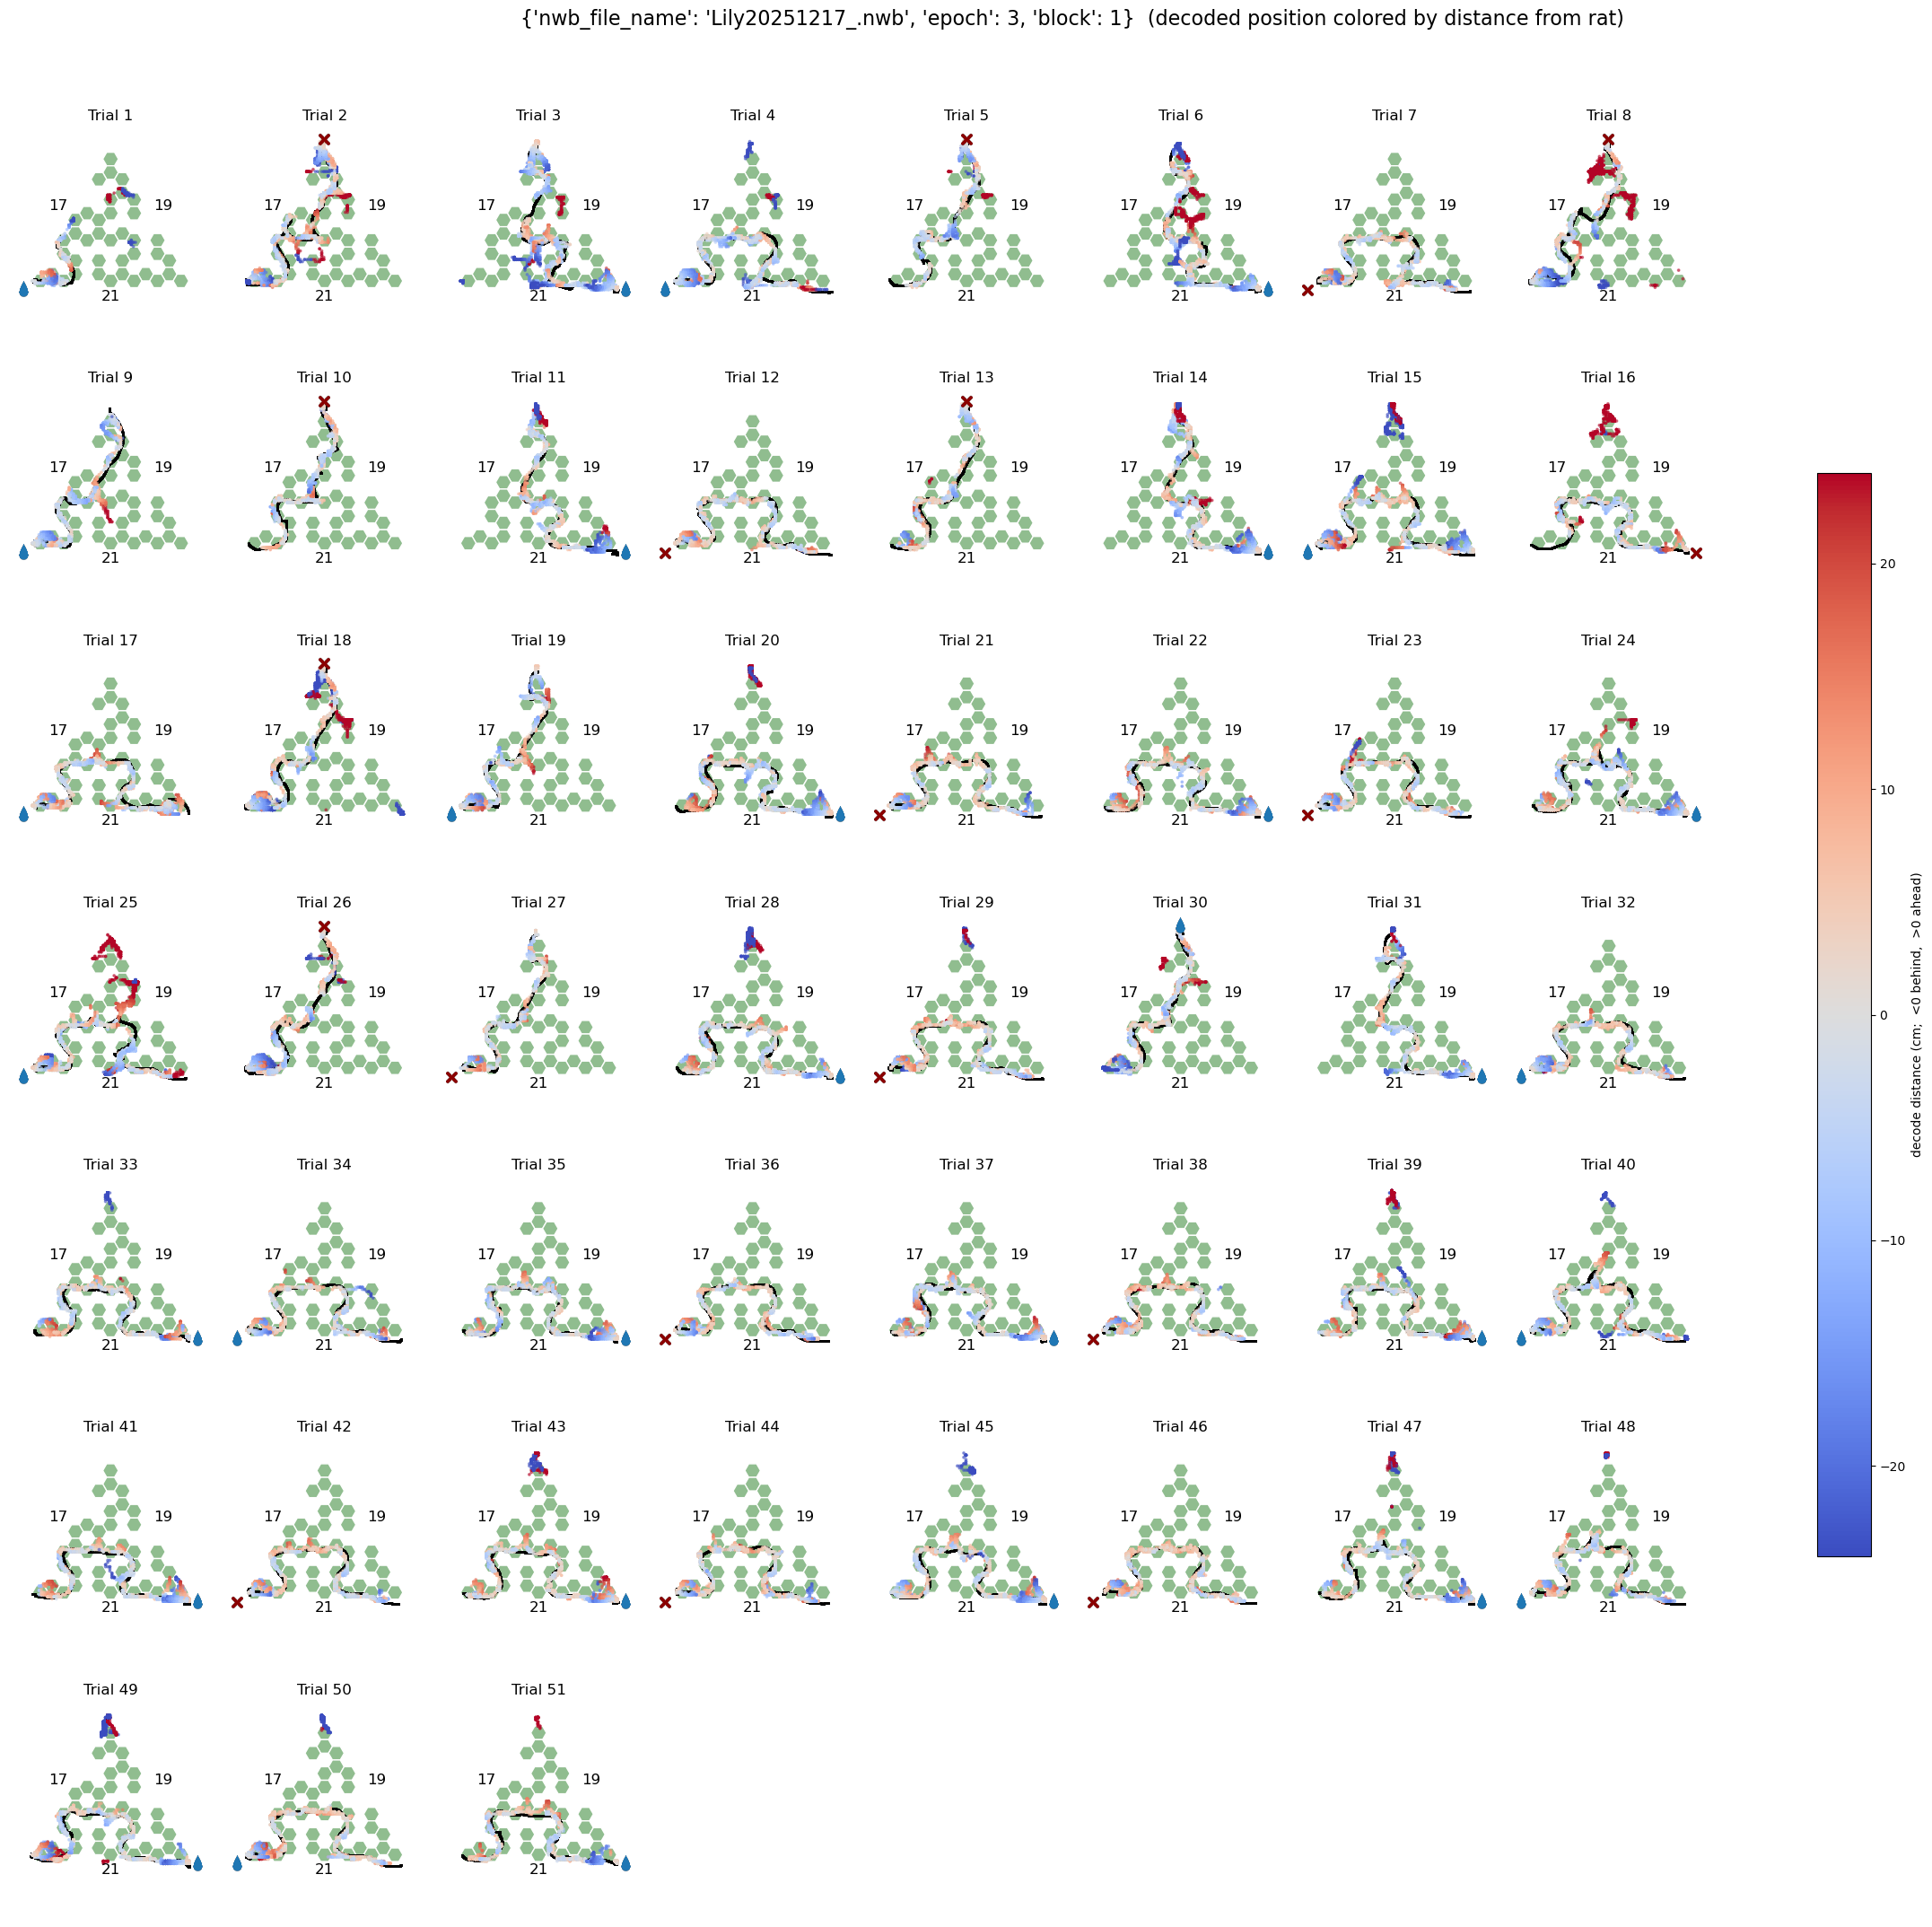

{'nwb_file_name': 'Lily20251217_.nwb', 'epoch': 3, 'block': 2}: HexmazeNoStim


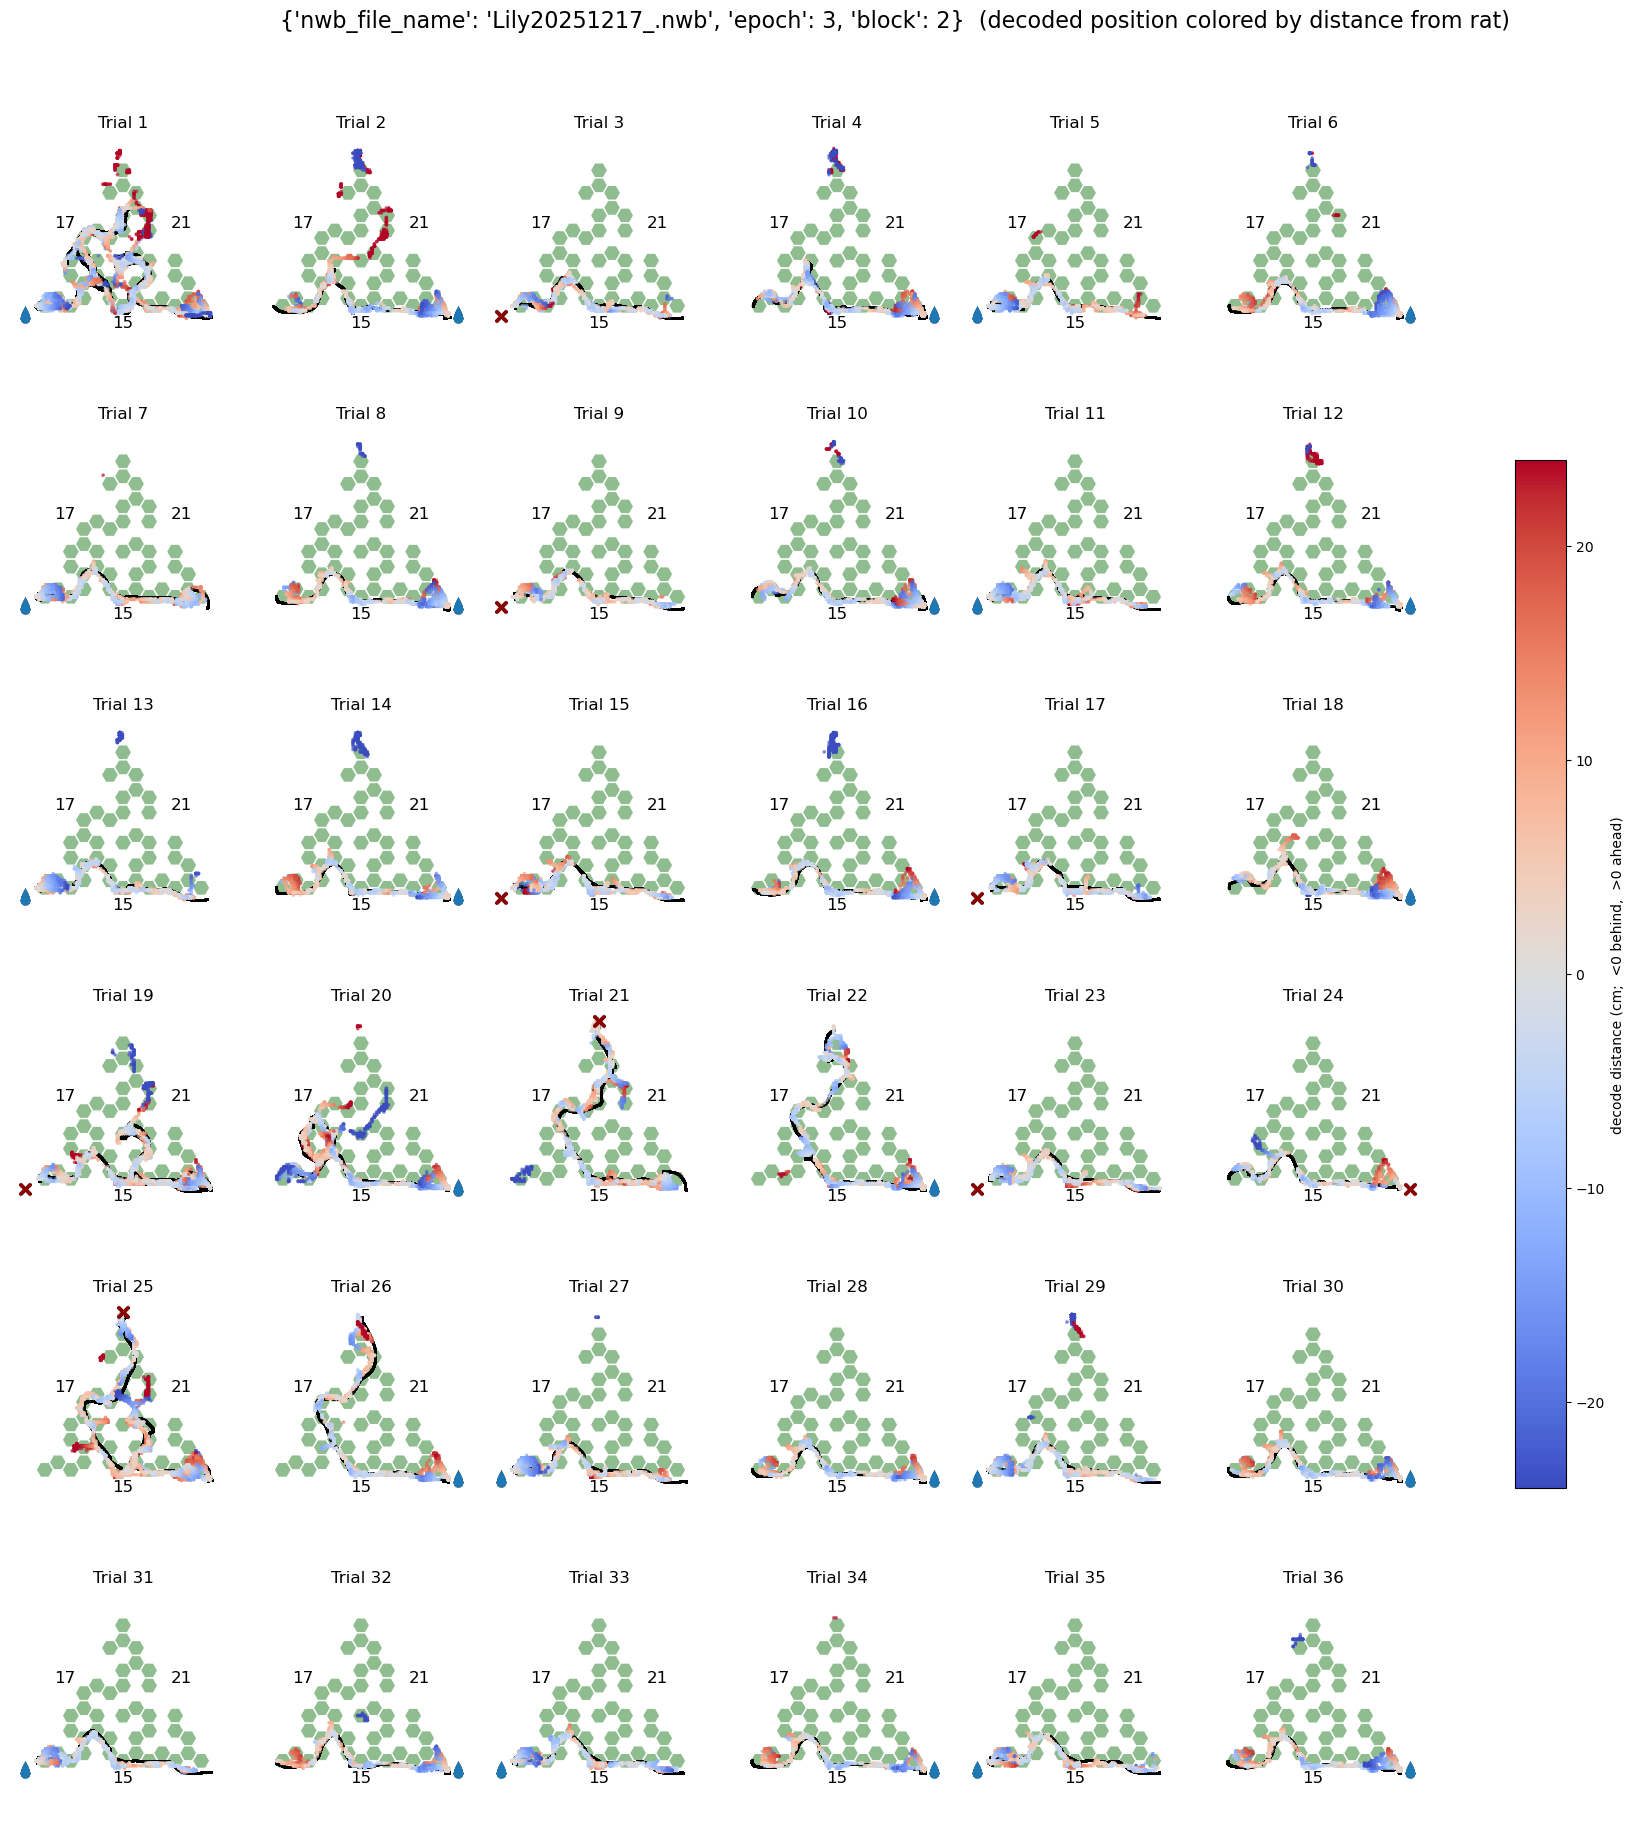

{'nwb_file_name': 'Lily20251217_.nwb', 'epoch': 3, 'block': 3}: HexmazeNoStim


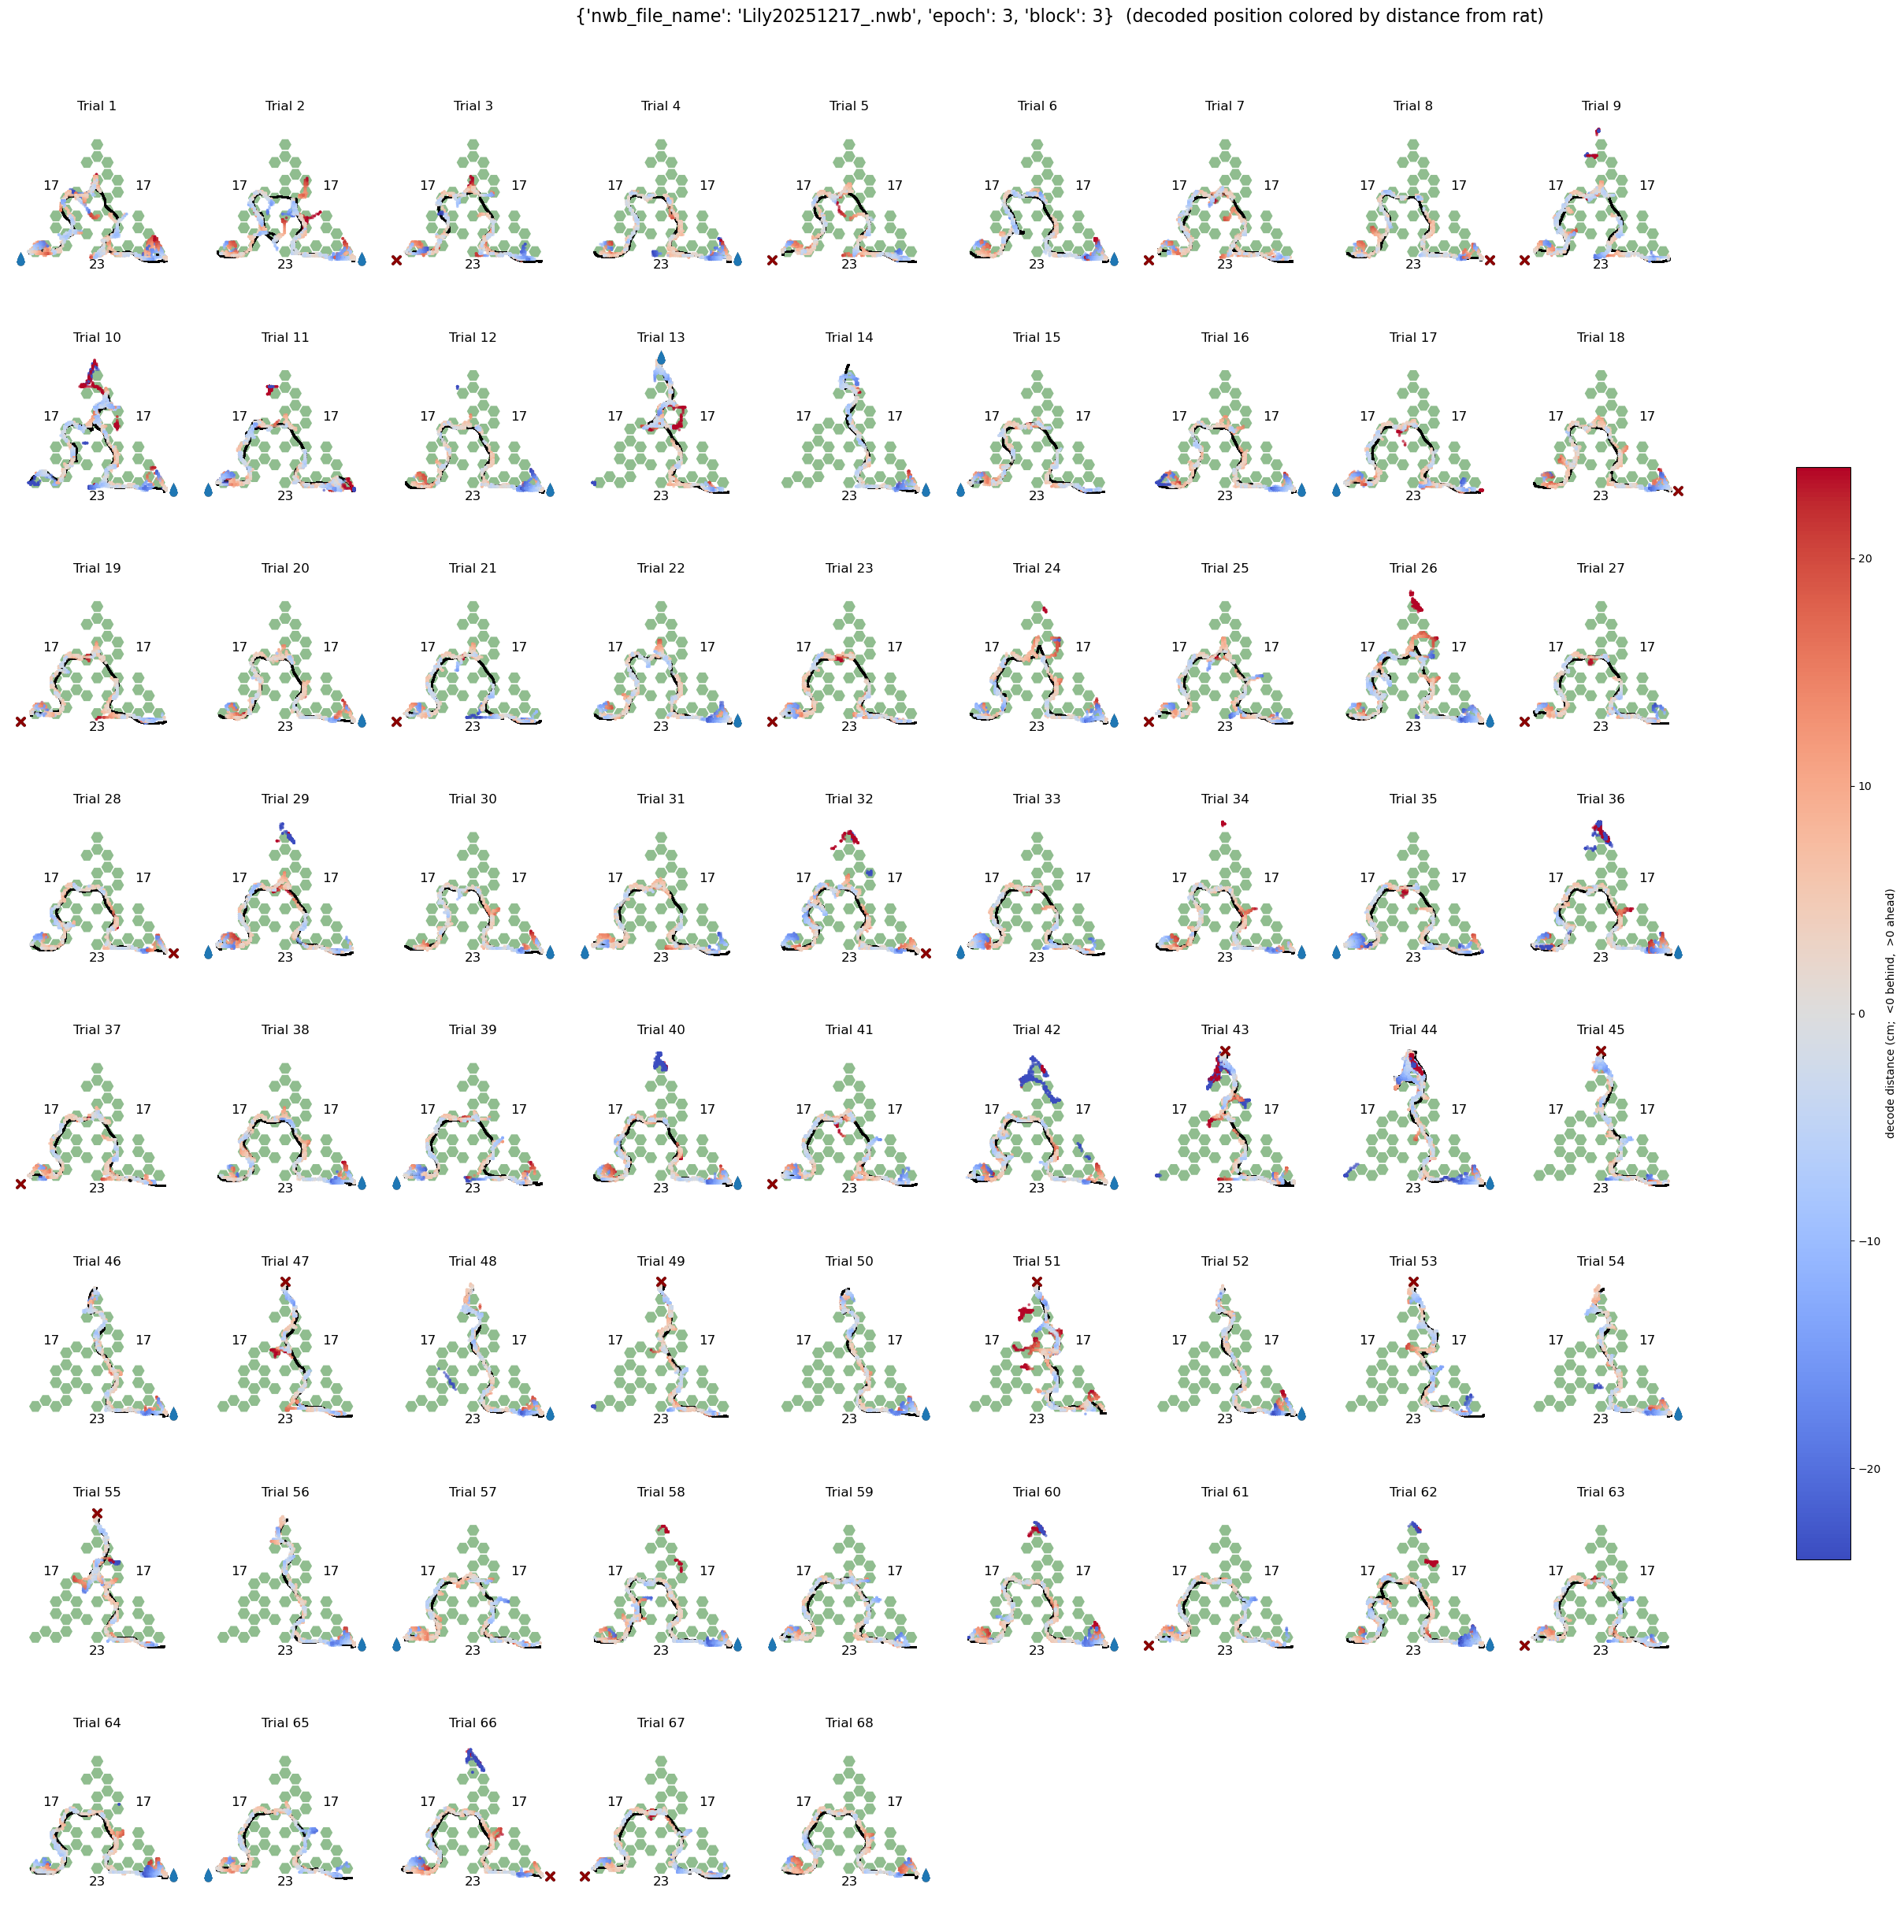

{'nwb_file_name': 'Lily20251217_.nwb', 'epoch': 3, 'block': 4}: HexmazeNoStim


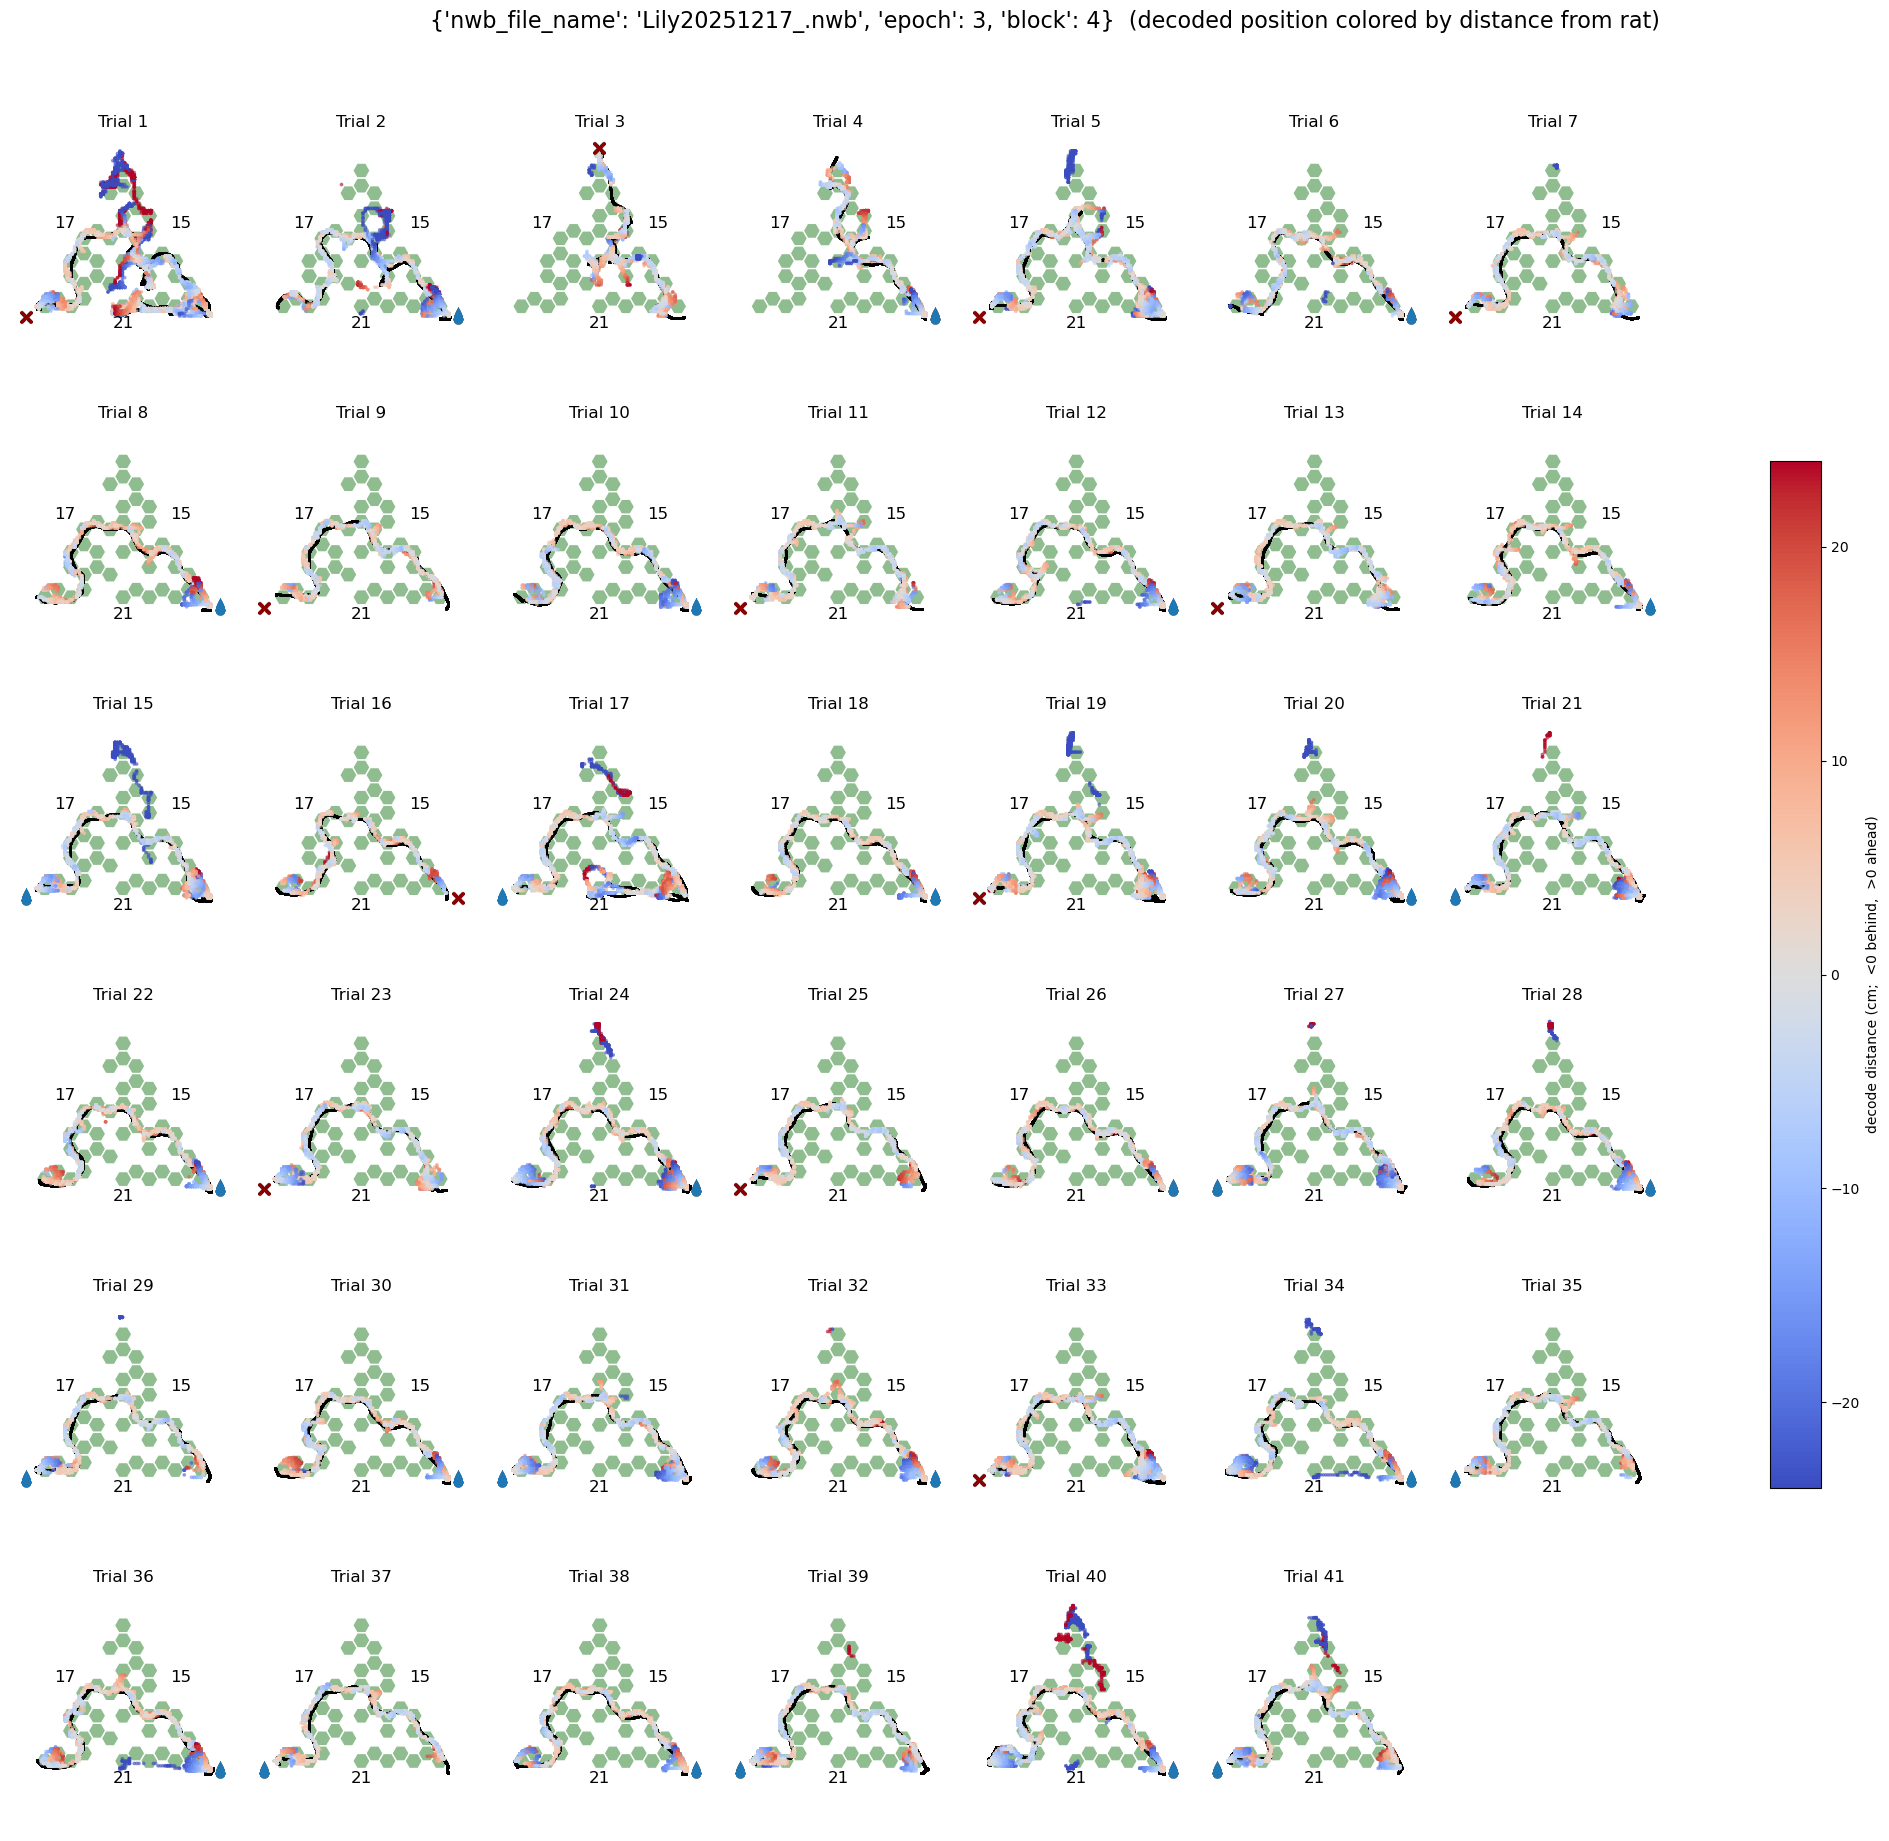

{'nwb_file_name': 'Lily20251217_.nwb', 'epoch': 3, 'block': 5}: HexmazeNoStim


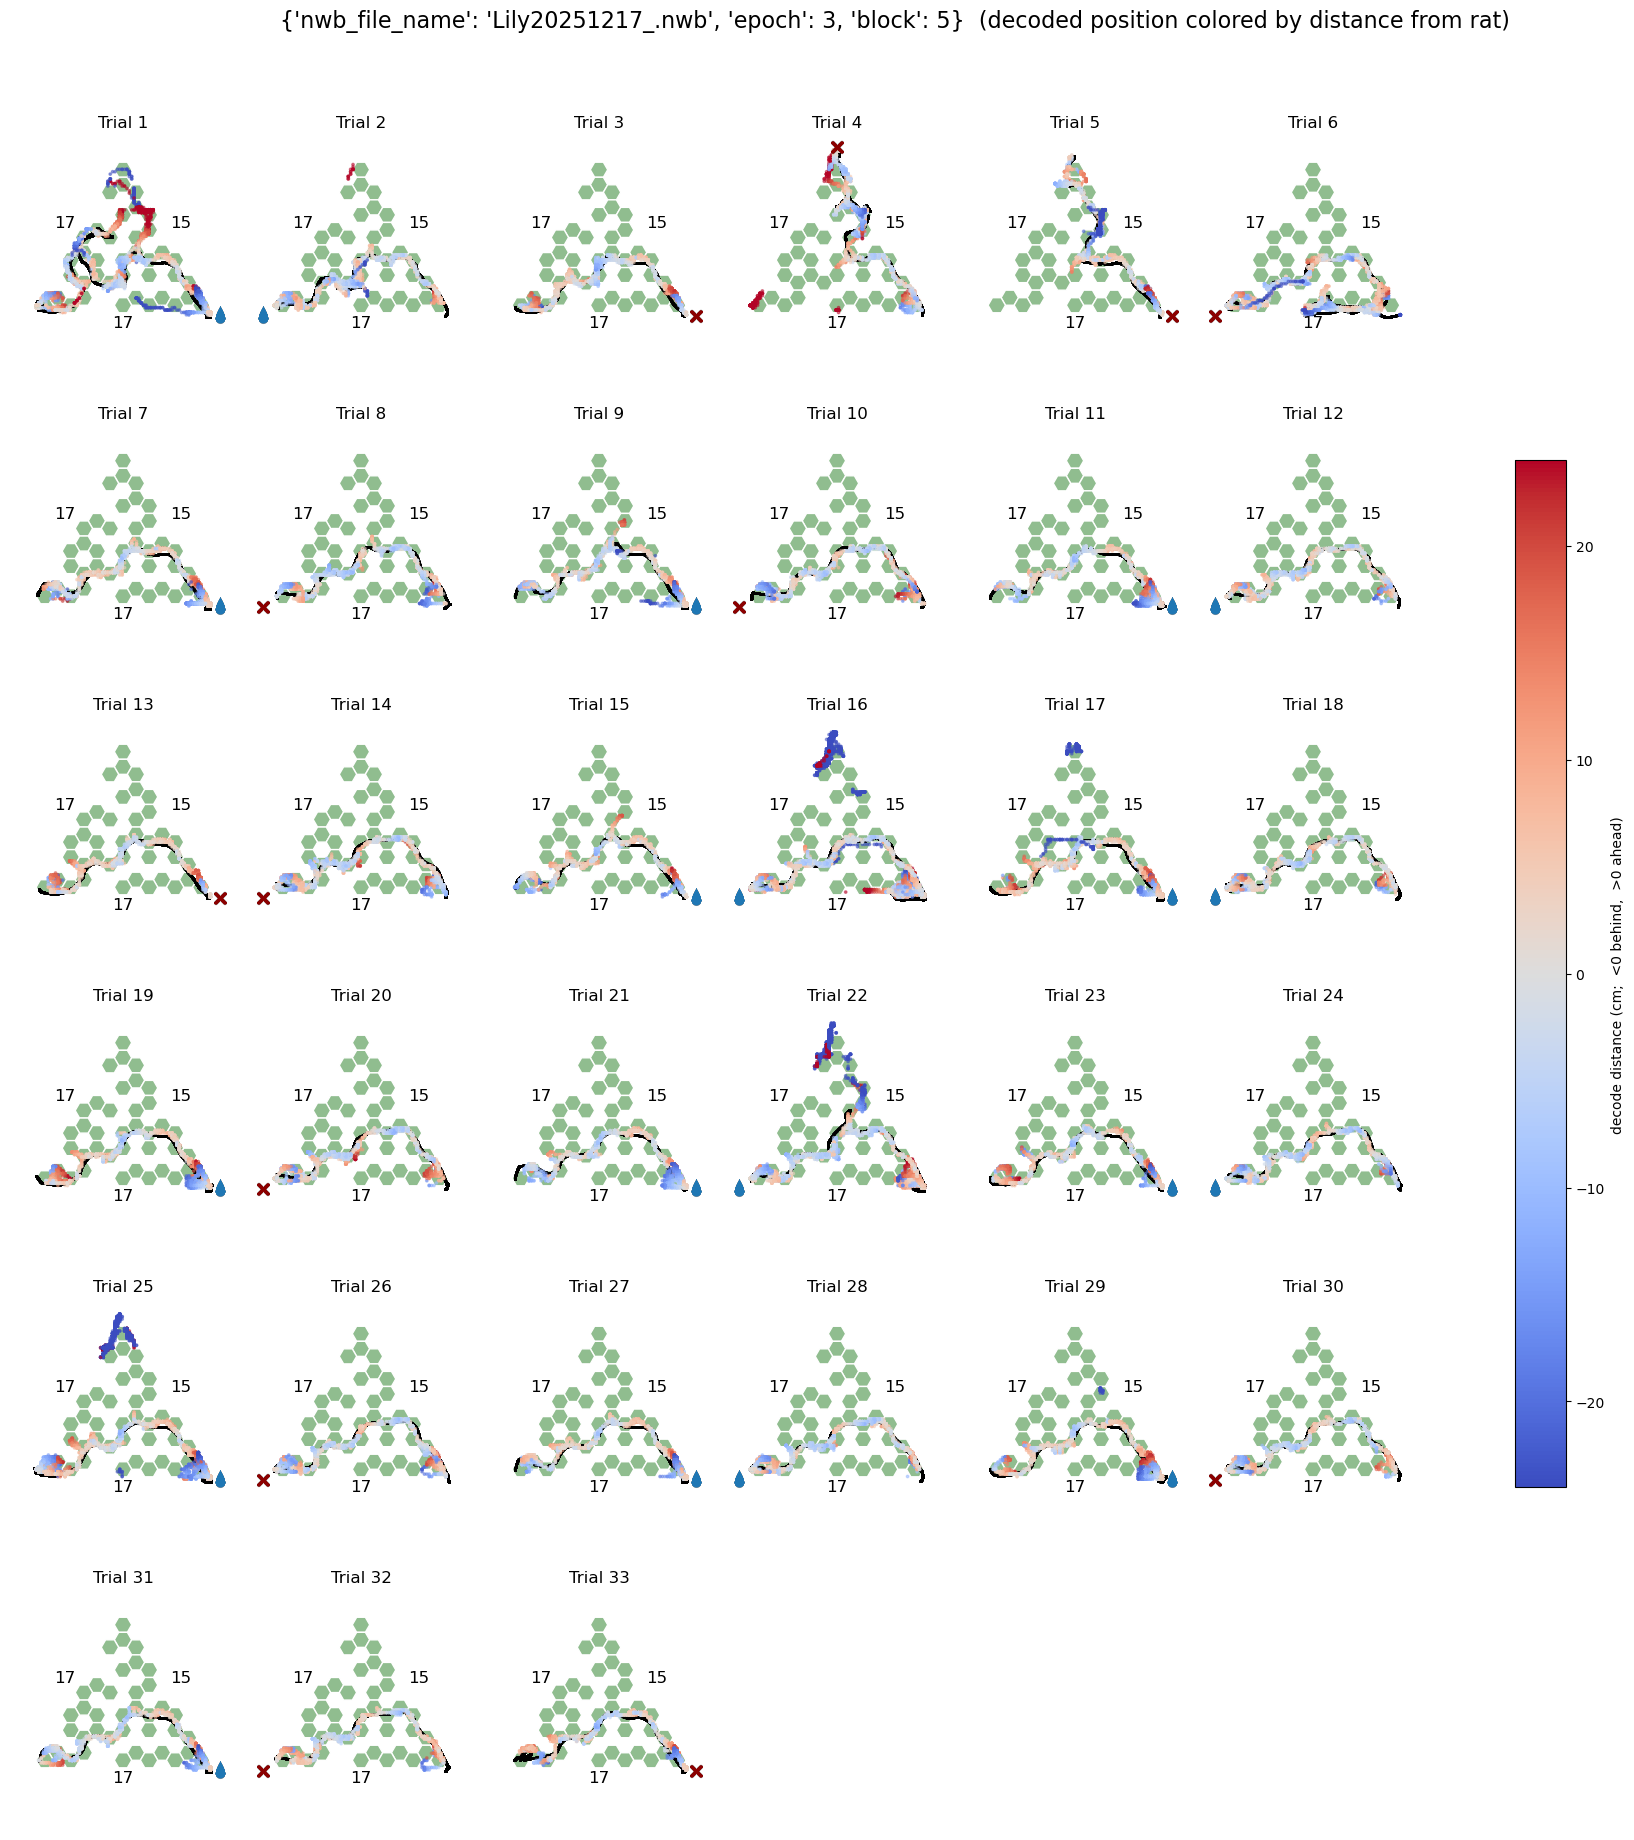

{'nwb_file_name': 'Lily20251217_.nwb', 'epoch': 7, 'block': 1}: HexmazeNoStim


/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altere

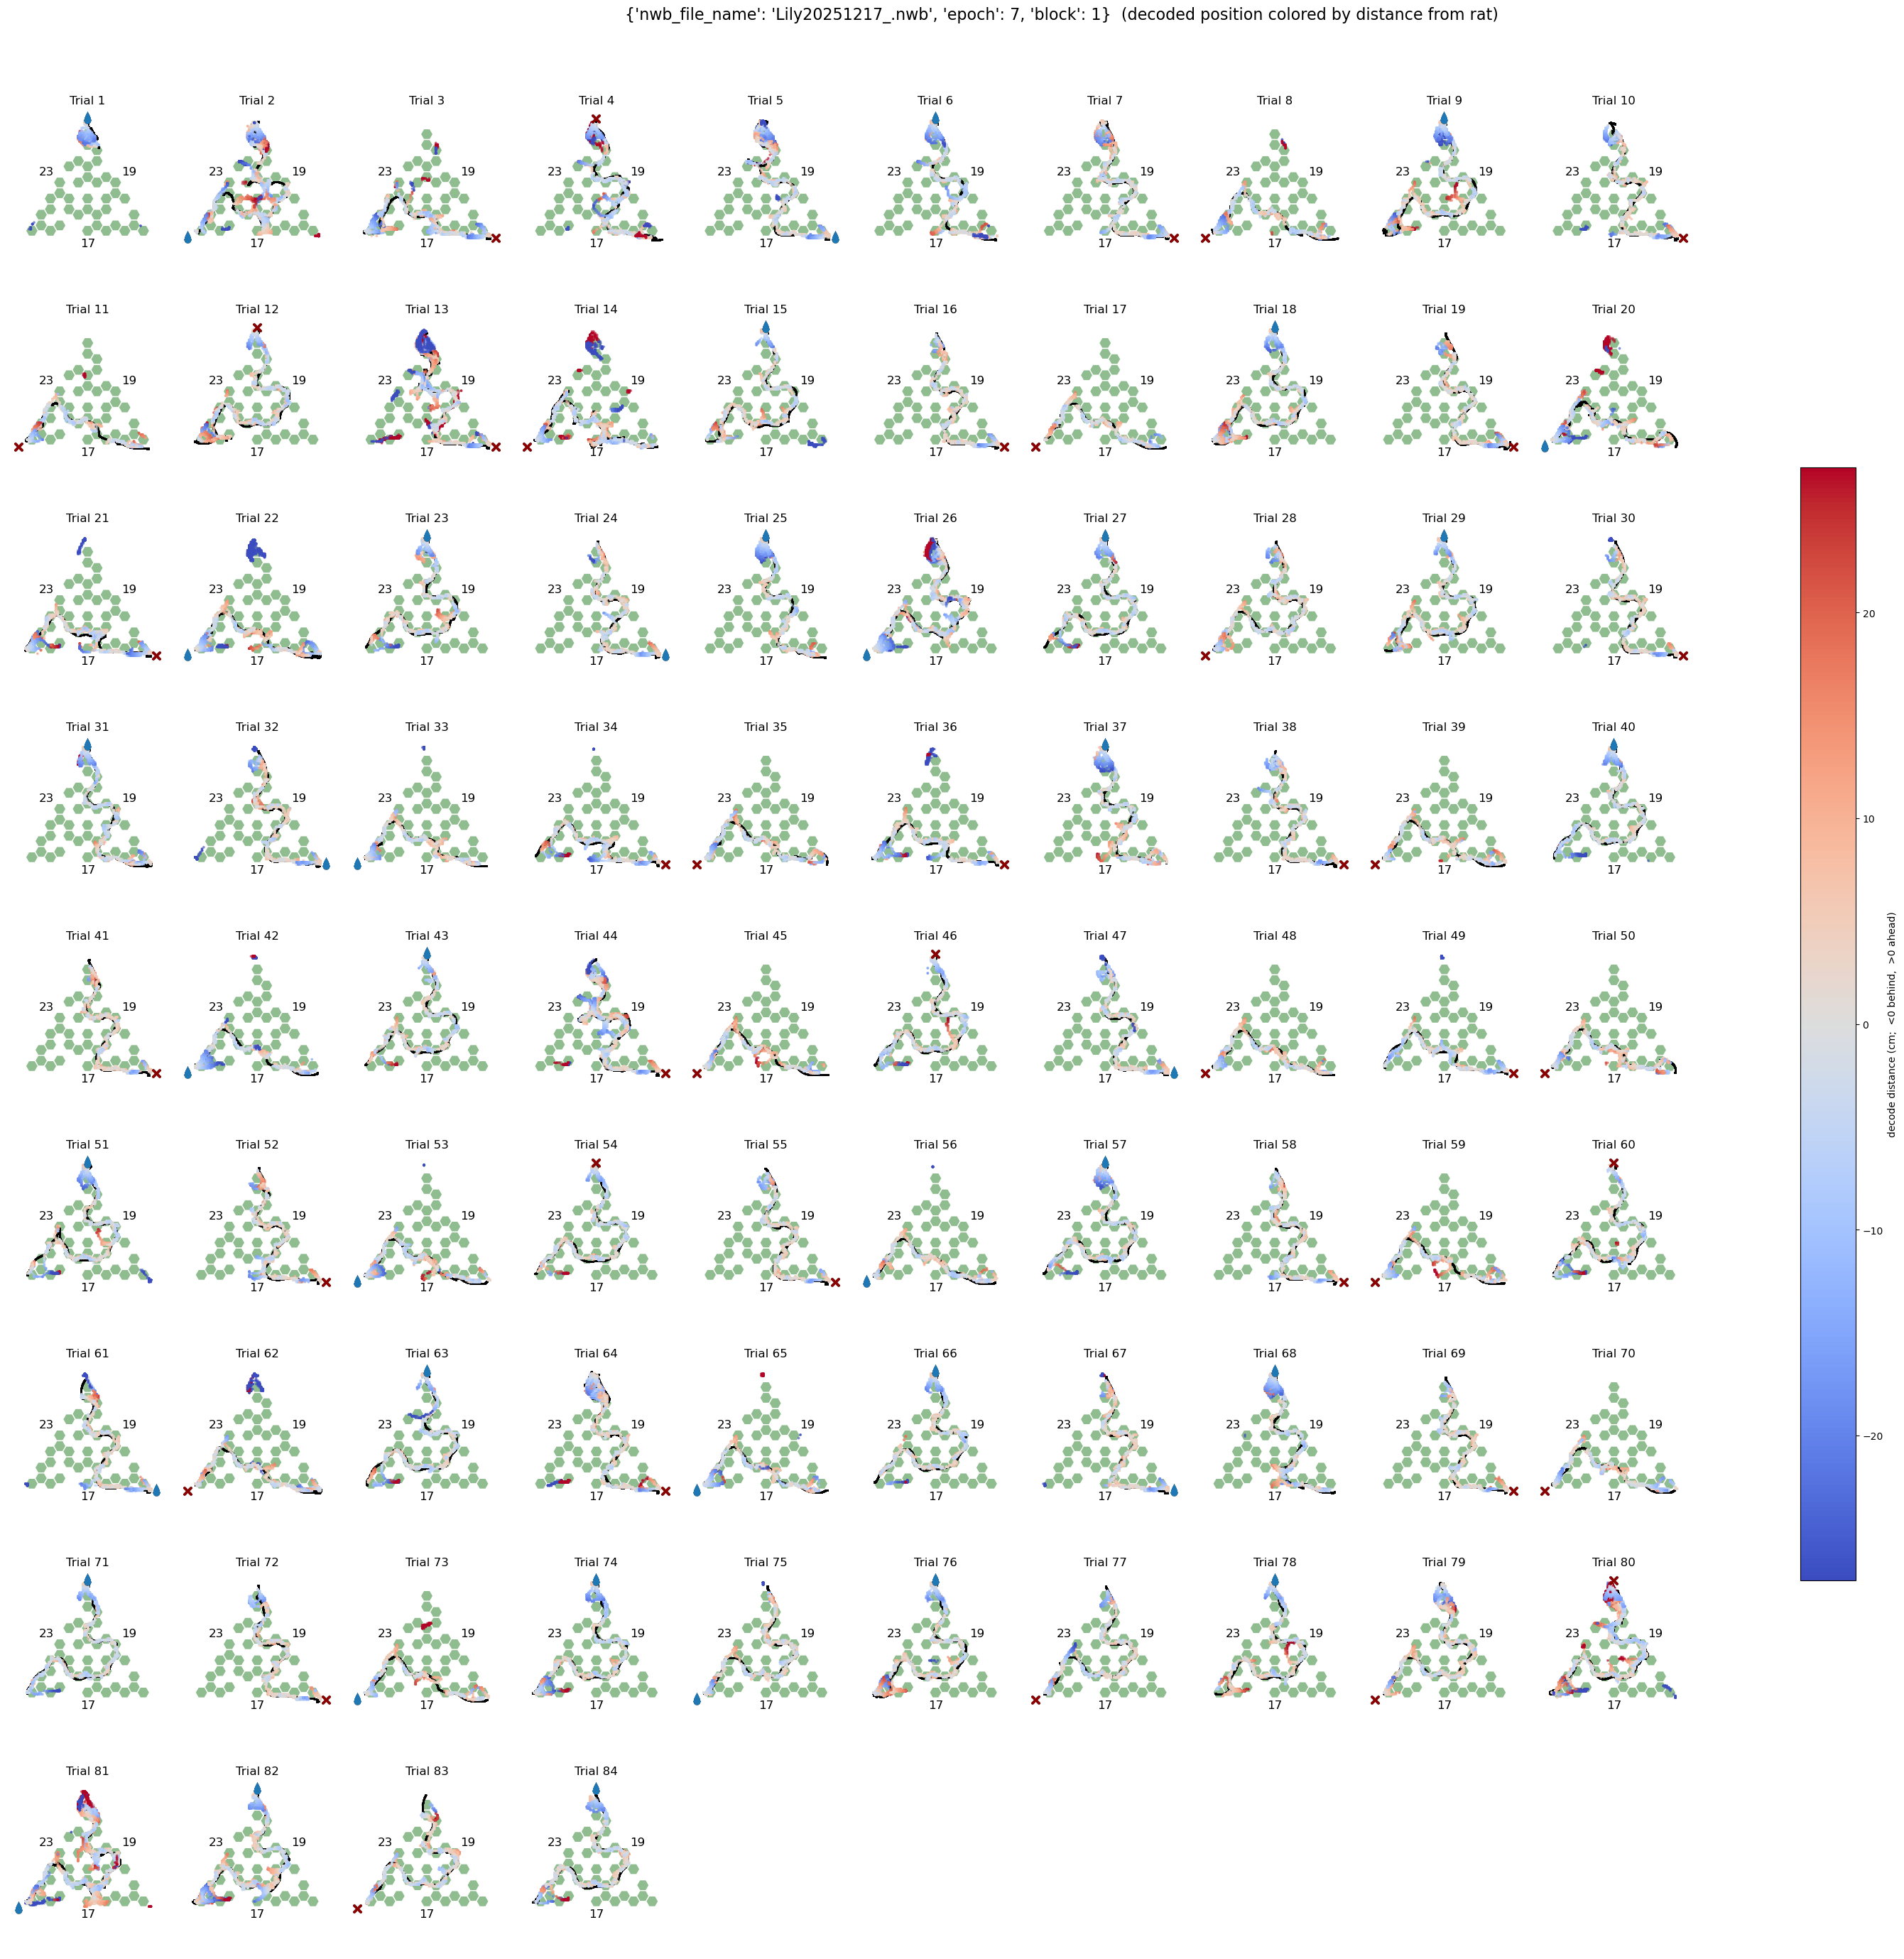

{'nwb_file_name': 'Lily20251217_.nwb', 'epoch': 7, 'block': 2}: HexmazeNoStim


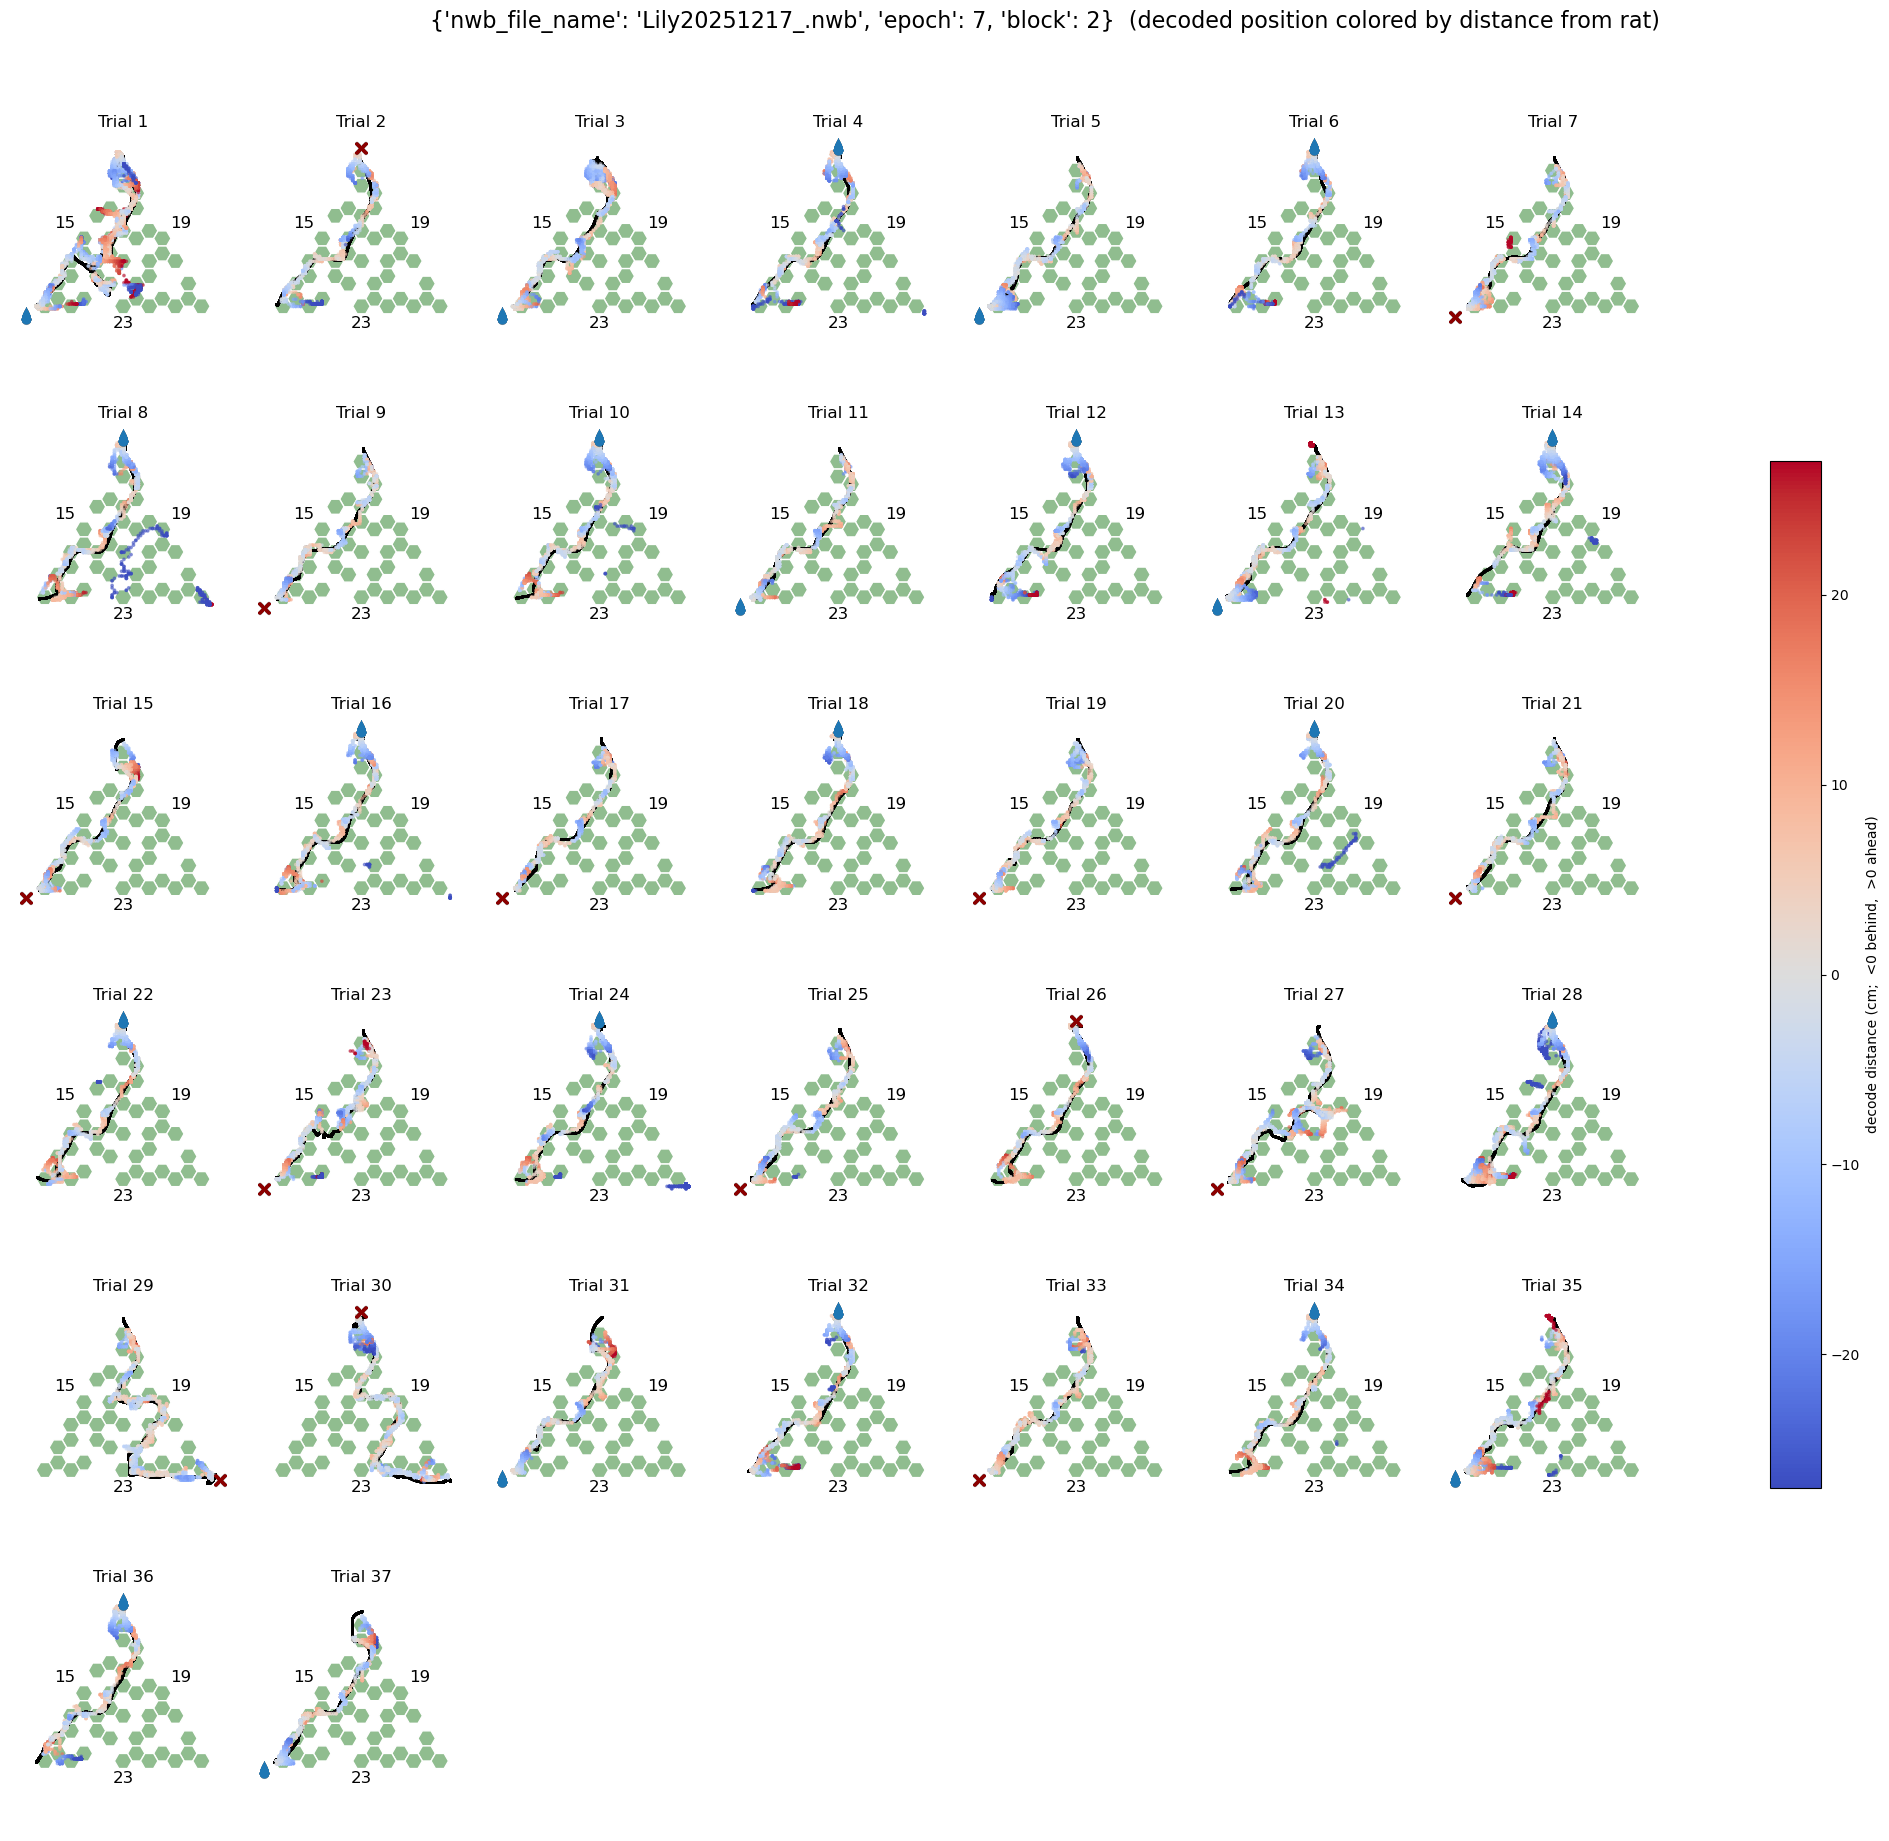

{'nwb_file_name': 'Lily20251217_.nwb', 'epoch': 7, 'block': 3}: HexmazeNoStim


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable

from hexmaze import plot_hex_maze

import spyglass.common as sgc
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock, HexCentroids
from spyglass_hexmaze.hex_maze_decoding import HexMazeDecodedPosition

restriction = {"nwb_file_name LIKE 'Lily%'"}

# Get decode keys based on restriction
decode_keys = (HexMazeDecodedPosition() & restriction).fetch("KEY", order_by="nwb_file_name, epoch")

# Only show decoded position if it meets these critera:
spatial_cov_threshold = 200 # 95% decode coverage must be less than this in cm2
speed_threshold = 2         # rat speed must be more than this in cm/s

CMAP_DIST = "coolwarm"      # blue = behind rat (negative), red = ahead (positive)

FIG_DIR = Path("figures/temp")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Loop through blocks (prob change only)
for key in (HexMazeBlock() & decode_keys & "task_type LIKE '%barrier%'").fetch("KEY", order_by="nwb_file_name, epoch, block"):

    print(f"{key}: {(sgc.Session() & key).fetch('session_description')[0]}")
    block = HexMazeBlock() & key
    trials = HexMazeBlock.Trial() & key
    num_trials = len(trials)
    maze, p_a, p_b, p_c = block.fetch1("config_id", "p_a", "p_b", "p_c")
    centroids = HexCentroids().get_core_hex_centroids_dict_cm(key)

    pos_df = (HexMazeDecodedPosition() & key).fetch1_dataframe()

    # Points that pass the quality filters (used for both the color limit and the plotting)
    keep = (pos_df["spatial_cov"] < spatial_cov_threshold) & (pos_df["speed"] > speed_threshold)
    # Symmetric color limit so 0 (rat's location) sits at the middle of the colormap.
    # Use the 95th percentile of |distance| so a few big outliers don't wash out the colors.
    absdist = pos_df.loc[keep, "decode_distance"].abs()
    vlim = float(np.nanpercentile(absdist, 95)) if len(absdist) else 1.0
    vlim = max(vlim, 1e-3)                                  # guard against all-zero
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vlim, vmax=vlim)

    ncols = int(np.ceil(np.sqrt(num_trials)))
    nrows = int(np.ceil(num_trials / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = np.array([axes]).flatten() if isinstance(axes, plt.Axes) else np.array(axes).flatten()
    fig.suptitle(f"{key}  (decoded position colored by distance from rat)", fontsize=16, y=1.02)

    for i, trial_info in enumerate(trials):
        start, end = (sgc.IntervalList() & trial_info).fetch1("valid_times")[0]
        df_trial = pos_df.loc[start:end]

        axes[i].set_title(f"Trial {i+1}")
        plot_hex_maze(
            ax=axes[i], barriers=maze, centroids=centroids, snap_centroids=True,
            invert_yaxis=True, show_barriers=False, show_hex_labels=False,
            # Show a reward droplet (rewarded) or no-reward X (omission) at the port the rat chose
            show_stats=True, reward=(trial_info["end_port"], bool(trial_info["reward"])),
            # Tint all background hexes light green for contrast with the coolwarm decode points
            highlight_hexes=set(centroids), highlight_colors=["#90bd8f"],
        )

        # Actual position in black
        axes[i].scatter(df_trial["position_x"], df_trial["position_y"], s=1, color="k")
        # Decoded position, colored by signed distance from the rat (blue=behind, red=ahead)
        pred = df_trial[(df_trial["spatial_cov"] < spatial_cov_threshold) &
                        (df_trial["speed"] > speed_threshold)]
        axes[i].scatter(pred["decode_position_x"], pred["decode_position_y"],
                        c=pred["decode_distance"], cmap=CMAP_DIST, norm=norm, s=3, alpha=0.5)

    for j in range(num_trials, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    # Shared colorbar for the whole block
    sm = ScalarMappable(norm=norm, cmap=CMAP_DIST); sm.set_array([])
    fig.colorbar(sm, ax=axes.tolist(), shrink=0.6, label="decode distance (cm;  <0 behind,  >0 ahead)")

    session_id = key["nwb_file_name"].replace("_.nwb", "")
    fig_path = FIG_DIR / f"{session_id}_epoch{key['epoch']}_block{key['block']}_distcolor_decode.png"
    fig.canvas.draw()
    #fig.savefig(fig_path, dpi=200, facecolor="white", bbox_inches="tight")
    #print(f"saved {fig_path}")
    plt.show()
